# Setting Up Mixed Precision for Faster MOdel Training:

In [45]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy= "mixed_float16")

# Importing Necessary Libraries:

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Importing Data:

In [47]:
from tensorflow.keras.datasets import cifar10

In [48]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [49]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

In [50]:
x_train.min(), x_train.max()

(0, 255)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
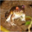

In [51]:
x_train[0]

In [52]:
y_train[0]

array([6], dtype=uint8)

# Plotting Some Data:

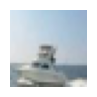

In [53]:
plt.figure(figsize= (1,1))
plt.imshow(x_train[100])
plt.axis(False)
plt.show()

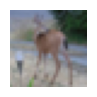

In [54]:
plt.figure(figsize= (1,1))
plt.imshow(x_test[100])
plt.axis(False)
plt.show()

# Normalizing The Data (Getting All Pixel Values Between 0 and 1) and Bringing Data into Desired Data Types:

In [55]:
x_train = x_train / 255
x_test = x_test / 255

x_train.min(), x_train.max(), x_test.min(), x_test.max()

(0.0, 1.0, 0.0, 1.0)

In [56]:
x_train.dtype, x_test.dtype, y_train.dtype, y_test.dtype

(dtype('float64'), dtype('float64'), dtype('uint8'), dtype('uint8'))

In [57]:
# Casting Labels to int32 Data Type:
y_train = tf.cast(y_train, tf.int32)
y_test = tf.cast(y_test, tf.int32)

In [58]:
x_train.dtype, x_test.dtype, y_train.dtype, y_test.dtype

(dtype('float64'), dtype('float64'), tf.int32, tf.int32)

# Creating Model:

## Creating Data Pipelines:

In [59]:
# Training Data:
train_features = tf.data.Dataset.from_tensor_slices(x_train)
train_labels = tf.data.Dataset.from_tensor_slices(y_train)
train_dataset = tf.data.Dataset.zip((train_features, train_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

# Validation Data:
test_features = tf.data.Dataset.from_tensor_slices(x_test)
test_labels = tf.data.Dataset.from_tensor_slices(y_test)
test_dataset = tf.data.Dataset.zip((test_features, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

## Creating, Compiling and Fitting Model:

In [66]:
tf.random.set_seed(42)

model = Sequential()

model.add(Input(shape= (32,32,3)))

model.add(Conv2D(filters= 128, kernel_size= 5, padding= "same", activation= "relu"))
model.add(MaxPool2D(pool_size= (2,2), padding= "same"))
model.add(Dropout(0.5))


model.add(Conv2D(filters= 64, kernel_size= 5, padding= "same", activation= "relu"))
model.add(MaxPool2D(pool_size= (2,2), padding= "same"))
model.add(Dropout(0.25))

model.add(Conv2D(filters= 32, kernel_size= 5, padding= "same", activation= "relu"))
model.add(MaxPool2D(pool_size= (2,2), padding= "same"))
model.add(Dropout(0.1))

model.add(Conv2D(filters= 16, kernel_size= 5, padding= "same", activation= "relu"))
model.add(MaxPool2D(pool_size= (2,2), padding= "same"))

model.add(Flatten())

model.add(Dense(256, activation= "relu"))

model.add(Dense(128, activation= "relu"))

model.add(Dense(10, activation= "softmax"))

# Compiling The Model:
model.compile(optimizer= Adam(),
              loss= SparseCategoricalCrossentropy(),
              metrics= ["accuracy"])

# Fitting The Model:
model.fit(train_dataset,
          epochs= 50,
          validation_data= test_dataset,
          validation_steps= int(0.25 * len(test_dataset)),
          callbacks= [EarlyStopping(monitor= "val_loss",
                                    patience= 3),
                      ReduceLROnPlateau(monitor= "val_loss",
                                        patience= 2)])

Epoch 1/50
1563/1563 [==============================] - 15s 7ms/step - loss: 1.7085 - accuracy: 0.3631 - val_loss: 1.3964 - val_accuracy: 0.5028 - lr: 0.0010
Epoch 2/50
1563/1563 [==============================] - 11s 7ms/step - loss: 1.3788 - accuracy: 0.5012 - val_loss: 1.2019 - val_accuracy: 0.5721 - lr: 0.0010
Epoch 3/50
1563/1563 [==============================] - 11s 7ms/step - loss: 1.2466 - accuracy: 0.5528 - val_loss: 1.0719 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 4/50
1563/1563 [==============================] - 11s 7ms/step - loss: 1.1532 - accuracy: 0.5903 - val_loss: 1.0226 - val_accuracy: 0.6346 - lr: 0.0010
Epoch 5/50
1563/1563 [==============================] - 12s 8ms/step - loss: 1.0979 - accuracy: 0.6105 - val_loss: 0.9694 - val_accuracy: 0.6647 - lr: 0.0010
Epoch 6/50
1563/1563 [==============================] - 12s 8ms/step - loss: 1.0515 - accuracy: 0.6280 - val_loss: 0.9615 - val_accuracy: 0.6711 - lr: 0.0010
Epoch 7/50
1563/1563 [==============================

## Evaluating The Model:

In [68]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 2s 6ms/step - loss: 0.7494 - accuracy: 0.7428


[0.7493609189987183, 0.7427999973297119]

## Prediction and Different Evaluation Metrics of Model:

In [71]:
model_pred_probs = model.predict(x_test)
model_pred_probs[:10], model_pred_probs.shape

313/313 [==============================] - 1s 3ms/step


(array([[6.8188e-04, 1.3247e-03, 4.9400e-03, 6.4111e-01, 5.7945e-03,
         2.7832e-01, 6.5796e-02, 7.1192e-04, 7.3147e-04, 7.3290e-04],
        [4.4823e-03, 2.6703e-03, 5.6207e-05, 9.3579e-06, 1.3828e-05,
         1.9670e-06, 2.3544e-05, 1.0133e-06, 9.9268e-01, 6.7711e-05],
        [4.1748e-01, 7.7820e-02, 1.7334e-02, 3.0422e-03, 6.4468e-03,
         1.8415e-03, 2.0733e-03, 3.0537e-03, 4.3750e-01, 3.3325e-02],
        [8.5205e-01, 1.3075e-03, 2.1362e-02, 2.0623e-04, 2.6264e-03,
         1.6057e-04, 2.5225e-04, 1.5903e-04, 1.2128e-01, 8.0872e-04],
        [3.9530e-04, 1.8656e-05, 1.3023e-02, 1.7899e-02, 5.5450e-02,
         7.4339e-04, 9.1260e-01, 7.2420e-05, 3.7014e-05, 2.9922e-05],
        [1.5199e-05, 4.3511e-06, 2.2182e-03, 2.9144e-02, 5.8365e-03,
         5.0850e-03, 9.5752e-01, 9.9540e-06, 1.5497e-06, 2.0146e-05],
        [3.1815e-03, 9.7314e-01, 6.6233e-04, 1.2951e-03, 6.9737e-05,
         3.9411e-04, 5.4264e-04, 6.7592e-05, 7.1907e-04, 2.0157e-02],
        [3.7937e-03, 4.4560

In [72]:
model_preds = tf.argmax(model_pred_probs, axis= 1)
model_preds[:10]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1])>

In [77]:
# Classification Report:
print(classification_report(y_test, model_preds))

              precision    recall  f1-score   support

           0       0.79      0.78      0.79      1000
           1       0.89      0.86      0.88      1000
           2       0.71      0.57      0.63      1000
           3       0.57      0.53      0.55      1000
           4       0.63      0.76      0.69      1000
           5       0.67      0.57      0.61      1000
           6       0.67      0.89      0.77      1000
           7       0.81      0.77      0.79      1000
           8       0.86      0.86      0.86      1000
           9       0.84      0.83      0.84      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



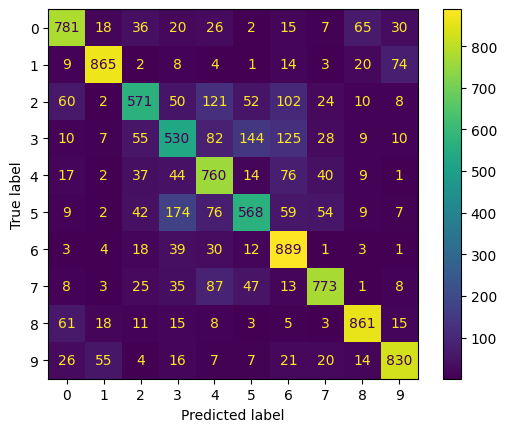

In [81]:
# Confusion Matrix:
cm = confusion_matrix(y_test, model_preds)
disp= ConfusionMatrixDisplay(cm)
disp.plot()